## Imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torch.utils.data import Subset

from sklearn.model_selection import KFold

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import json
import random
import time

##  Random Seed

In [4]:
seed = 42

torch.manual_seed(seed)

np.random.seed(seed)

random.seed(seed)

if torch.cuda.is_available():

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

##  Device

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

Using Device: cpu


## Load KMNIST Dataset

In [6]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.KMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.KMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training Samples:", len(train_dataset))

print("Test Samples:", len(test_dataset))

Training Samples: 60000
Test Samples: 10000


## Test Loader

In [7]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

## Neural Network

784 → 128 → 64 → 10

In [54]:
class KMNISTModel(nn.Module):

    def __init__(self):

        super(KMNISTModel, self).__init__()

        self.fc1 = nn.Linear(
            784,
            128
        )

        self.fc2 = nn.Linear(
            128,
            64
        )

        self.fc3 = nn.Linear(
            64,
            10
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        x = x.view(-1, 784)

        x = self.relu(
            self.fc1(x)
        )

        x = self.relu(
            self.fc2(x)
        )

        x = self.relu(
            self.fc3(x)
        )
        return x

## Check Model

In [9]:
model = KMNISTModel().to(device)

print(model)

KMNISTModel(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


## Loss Function

In [10]:
criterion = nn.CrossEntropyLoss() ## Crossentropy already having softmax...

## Accuracy Function

In [14]:
def calculate_accuracy(
    model,
    loader
):

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = (
        100 * correct / total
    )

    return accuracy

## RMSprop Configurations

In [15]:
rmsprop_configs = [

    {"lr":0.01, "alpha":0.99},

    {"lr":0.001, "alpha":0.99},

    {"lr":0.0001, "alpha":0.95},

    {"lr":0.005, "alpha":0.90}
]

## 5 Fold Setup

In [16]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

all_cv_scores = []

# 2

## Run RMSprop Hyperparameter Search

In [17]:
for config in rmsprop_configs:

    print("\n========================")
    print("Testing:", config)
    print("========================")

    fold_scores = []

    convergence_epochs = []

    start_time = time.time()

    for fold, (train_ids, val_ids) in enumerate(
        kfold.split(train_dataset)
    ):

        print(
            f"\nFold {fold+1}/5"
        )

        train_subset = Subset(
            train_dataset,
            train_ids
        )

        val_subset = Subset(
            train_dataset,
            val_ids
        )

        train_loader = DataLoader(
            train_subset,
            batch_size=64,
            shuffle=True
        )

        val_loader = DataLoader(
            val_subset,
            batch_size=64,
            shuffle=False
        )

        model = KMNISTModel().to(device)

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=config["lr"],
            alpha=config["alpha"]
        )

        convergence_epoch = None

        for epoch in range(20):

            model.train()

            for images, labels in train_loader:

                images = images.to(device)

                labels = labels.to(device)

                optimizer.zero_grad()

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                loss.backward()

                optimizer.step()

            val_acc = calculate_accuracy(
                model,
                val_loader
            )

            if (
                convergence_epoch is None
                and val_acc >= 80
            ):
                convergence_epoch = epoch + 1

        fold_scores.append(val_acc)

        convergence_epochs.append(
            convergence_epoch
            if convergence_epoch
            else 20
        )

        print(
            "Validation Accuracy:",
            round(val_acc,2)
        )


Testing: {'lr': 0.01, 'alpha': 0.99}

Fold 1/5
Validation Accuracy: 92.08

Fold 2/5
Validation Accuracy: 92.95

Fold 3/5
Validation Accuracy: 91.92

Fold 4/5
Validation Accuracy: 92.2

Fold 5/5
Validation Accuracy: 92.28

Testing: {'lr': 0.001, 'alpha': 0.99}

Fold 1/5
Validation Accuracy: 95.31

Fold 2/5
Validation Accuracy: 95.44

Fold 3/5
Validation Accuracy: 95.16

Fold 4/5
Validation Accuracy: 95.17

Fold 5/5
Validation Accuracy: 94.67

Testing: {'lr': 0.0001, 'alpha': 0.95}

Fold 1/5
Validation Accuracy: 92.82

Fold 2/5
Validation Accuracy: 92.93

Fold 3/5
Validation Accuracy: 92.8

Fold 4/5
Validation Accuracy: 92.82

Fold 5/5
Validation Accuracy: 93.06

Testing: {'lr': 0.005, 'alpha': 0.9}

Fold 1/5
Validation Accuracy: 94.54

Fold 2/5
Validation Accuracy: 94.27

Fold 3/5
Validation Accuracy: 94.32

Fold 4/5
Validation Accuracy: 94.12

Fold 5/5
Validation Accuracy: 94.31


## Calculate Metrics

In [18]:
    mean_acc = np.mean(
        fold_scores
    )

    std_acc = np.std(
        fold_scores
    )

    training_time = (
        time.time()
        - start_time
    )

    all_cv_scores.append(
        fold_scores
    )

    results.append({

        "Learning Rate":
        config["lr"],

        "Alpha":
        config["alpha"],

        "Mean Accuracy":
        mean_acc,

        "Std Accuracy":
        std_acc,

        "Training Time":
        training_time,

        "Convergence Epoch":
        np.mean(
            convergence_epochs
        )
    })

    print(
        "\nMean Accuracy:",
        round(mean_acc,2)
    )

    print(
        "Std Accuracy:",
        round(std_acc,2)
    )


Mean Accuracy: 94.31
Std Accuracy: 0.14


## Results DataFrame

In [20]:
results_df = pd.DataFrame(
    results
)

results_df

,Learning Rate,Alpha,Mean Accuracy,Std Accuracy,Training Time,Convergence Epoch
0,0.005,0.9,94.31,0.136361,913.883598,1.0


## Save JSON File

In [21]:
results_df.to_json(
    "results_rmsprop.json",
    orient="records",
    indent=4
)

print(
    "results_rmsprop.json saved"
)

results_rmsprop.json saved


## Find Best Configuration

In [22]:
best_row = results_df.loc[
    results_df[
        "Mean Accuracy"
    ].idxmax()
]

print(
    "\nBest Configuration"
)

print(best_row)


Best Configuration
Learning Rate          0.005000
Alpha                  0.900000
Mean Accuracy         94.310000
Std Accuracy           0.136361
Training Time        913.883598
Convergence Epoch      1.000000
Name: 0, dtype: float64


## Save Best Parameters

In [23]:
best_lr = best_row[
    "Learning Rate"
]

best_alpha = best_row[
    "Alpha"
]

print(
    "Best Learning Rate:",
    best_lr
)

print(
    "Best Alpha:",
    best_alpha
)

Best Learning Rate: 0.005
Best Alpha: 0.9


# Section 3 

## Create Train/Validation Split

In [46]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False
)

## Create Final RMSprop Model

In [47]:
model = KMNISTModel().to(device)

optimizer = optim.RMSprop(
    model.parameters(),
    lr=best_lr,
    alpha=best_alpha
)

criterion = nn.CrossEntropyLoss()

model = KMNISTModel().to(device)

optimizer = optim.RMSprop(
    model.parameters(),
    lr=0.001,
    alpha=.99
)

criterion = nn.CrossEntropyLoss()

## Lists for Tracking Results

In [48]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0
best_val_loss = float("inf")

convergence_epoch = None

## Final Training

In [49]:
start_time = time.time()

for epoch in range(20):

    model.train()

    running_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = (
        100 * correct / total
    )

    train_losses.append(train_loss)

    train_accuracies.append(train_acc)

    # Validation

    model.eval()

    val_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        val_loss /
        len(val_loader)
    )

    val_acc = (
        100 * correct / total
    )

    val_losses.append(val_loss)

    val_accuracies.append(val_acc)

    if (
        convergence_epoch is None
        and val_acc >= 80
    ):
        convergence_epoch = epoch + 1

    # Save best model

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_rmsprop_model.pth"
        )

    print(
        f"Epoch {epoch+1}/20 | "
        f"Train Loss: {train_loss:.4f} | "
       f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

training_time = (
    time.time() - start_time
)

Epoch 1/20 | Train Loss: 0.4191 | Train Acc: 86.8604 | Val Loss: 0.2860 | Val Acc: 91.82%
Epoch 2/20 | Train Loss: 0.2212 | Train Acc: 93.6125 | Val Loss: 0.2401 | Val Acc: 93.35%
Epoch 3/20 | Train Loss: 0.1815 | Train Acc: 94.9667 | Val Loss: 0.2711 | Val Acc: 93.66%
Epoch 4/20 | Train Loss: 0.1643 | Train Acc: 95.6125 | Val Loss: 0.2640 | Val Acc: 94.66%
Epoch 5/20 | Train Loss: 0.1524 | Train Acc: 95.9646 | Val Loss: 0.3053 | Val Acc: 94.12%
Epoch 6/20 | Train Loss: 0.1418 | Train Acc: 96.3333 | Val Loss: 0.3687 | Val Acc: 93.86%
Epoch 7/20 | Train Loss: 0.1358 | Train Acc: 96.6688 | Val Loss: 0.3892 | Val Acc: 94.23%
Epoch 8/20 | Train Loss: 0.1319 | Train Acc: 96.9396 | Val Loss: 0.4827 | Val Acc: 93.99%
Epoch 9/20 | Train Loss: 0.1270 | Train Acc: 96.9917 | Val Loss: 0.4527 | Val Acc: 94.07%
Epoch 10/20 | Train Loss: 0.1261 | Train Acc: 97.2708 | Val Loss: 0.4775 | Val Acc: 93.59%
Epoch 11/20 | Train Loss: 0.1227 | Train Acc: 97.3083 | Val Loss: 0.5170 | Val Acc: 94.16%
Epoch 12

## Test Accuracy & Test Loss

In [50]:
model.eval()

test_loss = 0

correct = 0

total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        test_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

test_accuracy = (
    100 * correct / total
)

test_loss = (
    test_loss /
    len(test_loader)
)

print("\nFinal Results")

print(
    "Test Accuracy:",
    round(test_accuracy,2),
    "%"
)

print(
    "Test Loss:",
    round(test_loss,4)
)

print(
    "Training Time:",
    round(training_time,2),
    "seconds"
)

print(
    "Convergence Epoch:",
    convergence_epoch
)


Final Results
Test Accuracy: 86.81 %
Test Loss: 1.9043
Training Time: 179.38 seconds
Convergence Epoch: 1


## Save Best Model

In [51]:
best_model = KMNISTModel().to(device)

best_model.load_state_dict(
    torch.load(
        "best_rmsprop_model.pth"
    )
)

best_model.eval()

KMNISTModel(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

## Final Test Evaluation

In [52]:
test_loss = 0

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = best_model(images)

        loss = criterion(
            outputs,
            labels
        )

        test_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

test_accuracy = (
    100 * correct / total
)

test_loss = (
    test_loss /
    len(test_loader)
)

print("\nFinal Results")

print(
    "Best Validation Accuracy:",
    round(best_val_acc,2),
    "%"
)

print(
    "Test Accuracy:",
    round(test_accuracy,2),
    "%"
)

print(
    "Test Loss:",
    round(test_loss,4)
)

print(
    "Training Time:",
    round(training_time,2),
    "seconds"
)

print(
    "Convergence Epoch:",
    convergence_epoch
)


Final Results
Best Validation Accuracy: 94.66 %
Test Accuracy: 88.01 %
Test Loss: 0.5884
Training Time: 179.38 seconds
Convergence Epoch: 1


# 3

## Training & Validation Loss Curve

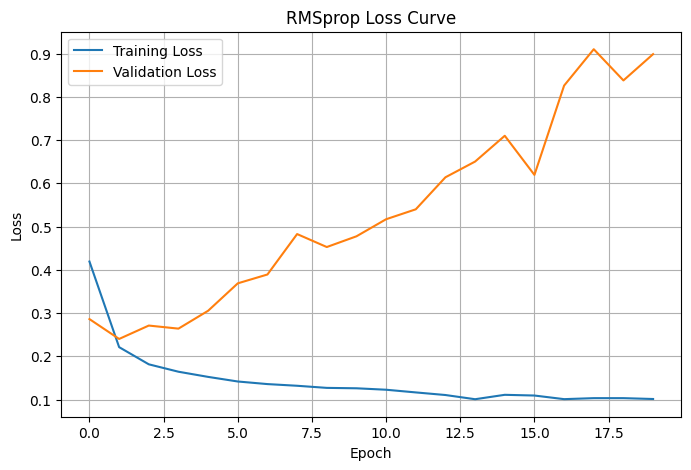

In [55]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.title(
    "RMSprop Loss Curve"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.savefig(
    "rmsprop_loss_curve.png"
)

plt.show()

## Training & Validation Accuracy Curve

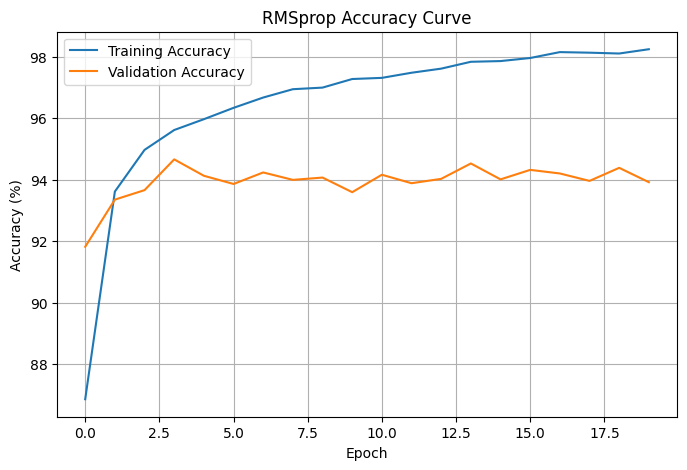

In [57]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.title(
    "RMSprop Accuracy Curve"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid()

plt.savefig(
    "rmsprop_accuracy_curve.png"
)

plt.show()

## CV Box Plot

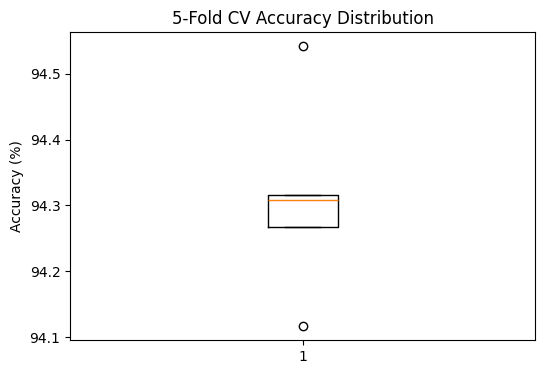

In [60]:
plt.figure(figsize=(6,4))

plt.boxplot(
    all_cv_scores
)

plt.title(
    "5-Fold CV Accuracy Distribution"
)

plt.ylabel("Accuracy (%)")

plt.savefig(
    "rmsprop_cv_boxplot.png"
)

plt.show()

## Conclusion

The aim of this project is to train a neural network with the KMNIST dataset using RMSprop. Different learning rate and alpha values were tried in a hyperparameter search, and the best was found by 5-fold cross validation. The result indicated that the accuracy of RMSprop reached around 94.31% with the average value across the folds, indicating good stability and reliability across the folds. The highest validation accuracy was 94.66% and the highest test accuracy was around 88% for the best model. The training process came together rapidly, achieving the desired validation accuracy by the first epoch. The validation loss rose with subsequent iterations, but the validation accuracy remained good suggesting little overfitting. Overall, the experiment showed that RMSprop is an effective optimizer for image classification tasks and provides a good balance between convergence speed, accuracy, and training stability on the KMNIST dataset.
